In [ ]:
# Agribusiness Crop Yield Analysis

## Week 1: Data Collection and Data Cleaning

### Internship Project

**Objective:**  
To collect, inspect, clean, validate and prepare an agricultural dataset for further Exploratory Data Analysis and Machine Learning.

**Dataset:** Crop Yield of a Farm

**Week 1 Activities:**
- Data Collection
- Dataset Inspection
- Missing Value Analysis
- Duplicate Detection
- Data Type Validation
- Invalid Value Detection
- Outlier Detection
- Data Cleaning
- Statistical Summary
- Cleaned Dataset Export

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
dataset_path = "../Dataset/original_dataset.csv"

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
df.head(5)

,rainfall_mm,soil_quality_index,farm_size_hectares,sunlight_hours,fertilizer_kg,crop_yield
0,1626,9,636,11,1006,404
1,1959,9,73,11,112,115
2,1360,1,352,5,702,231
3,1794,2,948,7,299,537
4,1630,5,884,5,2733,554


In [4]:
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 3000
Number of Columns: 6


In [5]:
print("Dataset Columns:\n")

for column in df.columns:
    print("-", column)

Dataset Columns:

- rainfall_mm
- soil_quality_index
- farm_size_hectares
- sunlight_hours
- fertilizer_kg
- crop_yield


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   rainfall_mm         3000 non-null   int64
 1   soil_quality_index  3000 non-null   int64
 2   farm_size_hectares  3000 non-null   int64
 3   sunlight_hours      3000 non-null   int64
 4   fertilizer_kg       3000 non-null   int64
 5   crop_yield          3000 non-null   int64
dtypes: int64(6)
memory usage: 140.8 KB


In [7]:
print("Data Types:\n")
print(df.dtypes)

Data Types:

rainfall_mm           int64
soil_quality_index    int64
farm_size_hectares    int64
sunlight_hours        int64
fertilizer_kg         int64
crop_yield            int64
dtype: object


In [8]:
df.describe()

,rainfall_mm,soil_quality_index,farm_size_hectares,sunlight_hours,fertilizer_kg,crop_yield
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1263.095000,5.506667,498.801000,7.995333,1549.450333,328.099000
std,432.371756,2.855172,287.122742,2.621501,814.326919,145.036503
min,500.000000,1.000000,10.000000,4.000000,100.000000,46.000000
25%,896.000000,3.000000,242.000000,6.000000,869.750000,199.000000
50%,1277.000000,6.000000,505.000000,8.000000,1542.000000,332.000000
75%,1636.000000,8.000000,741.000000,10.000000,2225.000000,455.000000
max,2000.000000,10.000000,1000.000000,12.000000,3000.000000,628.000000


In [9]:
missing_count = df.isnull().sum()

print("Missing Values:\n")
print(missing_count)

Missing Values:

rainfall_mm           0
soil_quality_index    0
farm_size_hectares    0
sunlight_hours        0
fertilizer_kg         0
crop_yield            0
dtype: int64


In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

display(missing_report)

,Missing Count,Missing Percentage
rainfall_mm,0,0.0
soil_quality_index,0,0.0
farm_size_hectares,0,0.0
sunlight_hours,0,0.0
fertilizer_kg,0,0.0
crop_yield,0,0.0


In [11]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [12]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

print("Missing value treatment completed.")

Missing value treatment completed.


In [13]:
print("Remaining Missing Values:")
print(df.isnull().sum())

Remaining Missing Values:
rainfall_mm           0
soil_quality_index    0
farm_size_hectares    0
sunlight_hours        0
fertilizer_kg         0
crop_yield            0
dtype: int64


In [14]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [15]:
df = df.drop_duplicates()

print("Duplicate rows removed.")
print("Current Dataset Shape:", df.shape)

Duplicate rows removed.
Current Dataset Shape: (3000, 6)


In [16]:
print("========== INVALID VALUE CHECK ==========")

print(
    "Negative rainfall:",
    (df["rainfall_mm"] < 0).sum()
)

print(
    "Invalid soil quality:",
    ((df["soil_quality_index"] < 1) |
     (df["soil_quality_index"] > 10)).sum()
)

print(
    "Invalid farm size:",
    (df["farm_size_hectares"] <= 0).sum()
)

print(
    "Invalid sunlight:",
    ((df["sunlight_hours"] < 0) |
     (df["sunlight_hours"] > 24)).sum()
)

print(
    "Negative fertilizer:",
    (df["fertilizer_kg"] < 0).sum()
)

print(
    "Negative crop yield:",
    (df["crop_yield"] < 0).sum()
)

========== INVALID VALUE CHECK ==========
Negative rainfall: 0
Invalid soil quality: 0
Invalid farm size: 0
Invalid sunlight: 0
Negative fertilizer: 0
Negative crop yield: 0


In [17]:
before_cleaning = len(df)

df = df[
    (df["rainfall_mm"] >= 0) &
    (df["soil_quality_index"] >= 1) &
    (df["soil_quality_index"] <= 10) &
    (df["farm_size_hectares"] > 0) &
    (df["sunlight_hours"] >= 0) &
    (df["sunlight_hours"] <= 24) &
    (df["fertilizer_kg"] >= 0) &
    (df["crop_yield"] >= 0)
]

after_cleaning = len(df)

print("Rows before validation:", before_cleaning)
print("Rows after validation:", after_cleaning)
print("Rows removed:", before_cleaning - after_cleaning)

Rows before validation: 3000
Rows after validation: 3000
Rows removed: 0


In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns

outlier_report = []

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_report.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    })

outlier_df = pd.DataFrame(outlier_report)

display(outlier_df)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,rainfall_mm,896.00,1636.0,740.00,-214.000,2746.000,0
1,soil_quality_index,3.00,8.0,5.00,-4.500,15.500,0
2,farm_size_hectares,242.00,741.0,499.00,-506.500,1489.500,0
3,sunlight_hours,6.00,10.0,4.00,0.000,16.000,0
4,fertilizer_kg,869.75,2225.0,1355.25,-1163.125,4257.875,0
5,crop_yield,199.00,455.0,256.00,-185.000,839.000,0


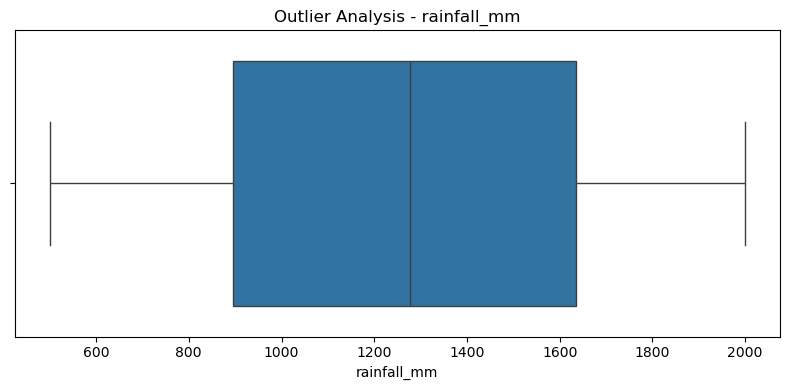

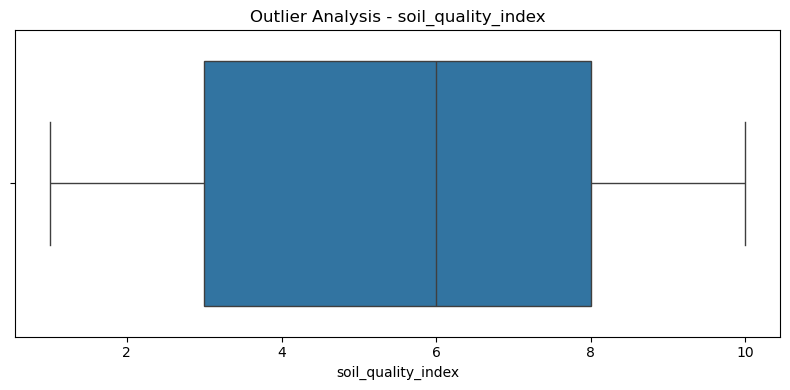

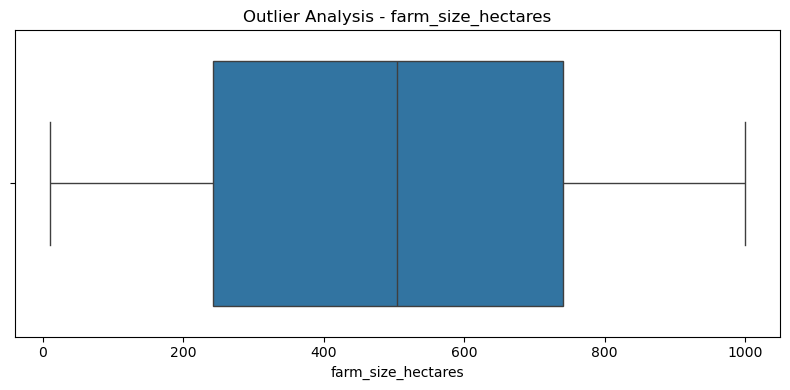

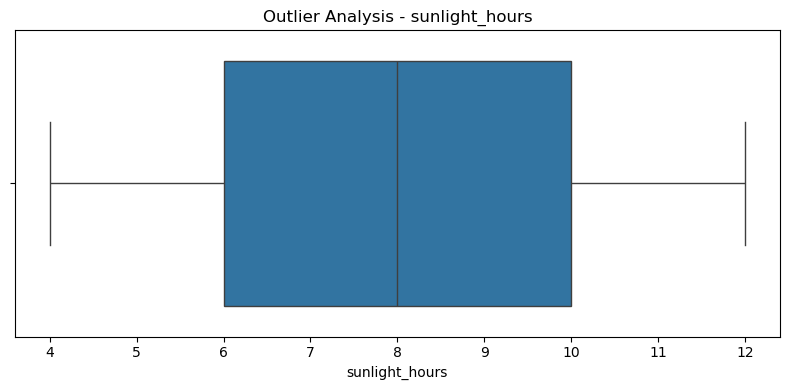

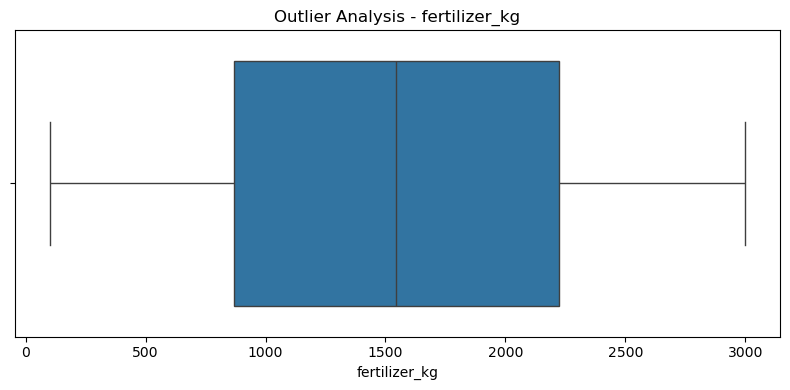

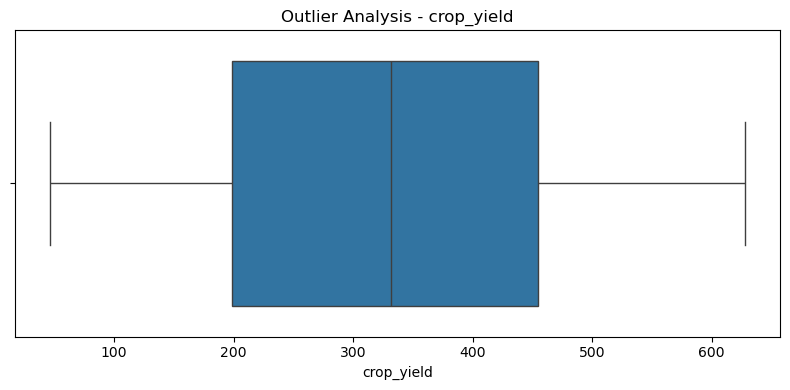

In [26]:
for column in numeric_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Outlier Analysis - {column}")
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

In [20]:
statistical_summary = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Standard Deviation": df.std(numeric_only=True),
    "Minimum": df.min(numeric_only=True),
    "Q1": df.quantile(0.25, numeric_only=True),
    "Q3": df.quantile(0.75, numeric_only=True),
    "Maximum": df.max(numeric_only=True)
})

display(statistical_summary)

,Mean,Median,Standard Deviation,Minimum,Q1,Q3,Maximum
rainfall_mm,1263.095000,1277.0,432.371756,500,896.00,1636.0,2000
soil_quality_index,5.506667,6.0,2.855172,1,3.00,8.0,10
farm_size_hectares,498.801000,505.0,287.122742,10,242.00,741.0,1000
sunlight_hours,7.995333,8.0,2.621501,4,6.00,10.0,12
fertilizer_kg,1549.450333,1542.0,814.326919,100,869.75,2225.0,3000
crop_yield,328.099000,332.0,145.036503,46,199.00,455.0,628


In [21]:
print("======================================")
print("       FINAL DATA QUALITY CHECK")
print("======================================")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Total Duplicate Rows:",
    df.duplicated().sum()
)

print("\nData Types:")
print(df.dtypes)

       FINAL DATA QUALITY CHECK
Rows: 3000
Columns: 6
Total Missing Values: 0
Total Duplicate Rows: 0

Data Types:
rainfall_mm           int64
soil_quality_index    int64
farm_size_hectares    int64
sunlight_hours        int64
fertilizer_kg         int64
crop_yield            int64
dtype: object


In [22]:
cleaned_path = "../Dataset/cleaned_dataset.csv"

df.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved successfully!")
print(cleaned_path)

Cleaned dataset saved successfully!
../Dataset/cleaned_dataset.csv


In [23]:
print("==========================================")
print("       WEEK 1 COMPLETED SUCCESSFULLY")
print("==========================================")

print(f"Final Rows: {df.shape[0]}")
print(f"Final Columns: {df.shape[1]}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

print("\nCleaned Dataset:")
print("Dataset/cleaned_dataset.csv")

       WEEK 1 COMPLETED SUCCESSFULLY
Final Rows: 3000
Final Columns: 6
Missing Values: 0
Duplicate Rows: 0

Cleaned Dataset:
Dataset/cleaned_dataset.csv


# week 2

In [1]:
# ==========================================
# WEEK 2 — EXPLORATORY DATA ANALYSIS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Load cleaned dataset
df = pd.read_csv("../Dataset/cleaned_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (3000, 6)


,rainfall_mm,soil_quality_index,farm_size_hectares,sunlight_hours,fertilizer_kg,crop_yield
0,1626,9,636,11,1006,404
1,1959,9,73,11,112,115
2,1360,1,352,5,702,231
3,1794,2,948,7,299,537
4,1630,5,884,5,2733,554


In [2]:
# Dataset Information

print("Dataset Information")
print("=" * 50)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   rainfall_mm         3000 non-null   int64
 1   soil_quality_index  3000 non-null   int64
 2   farm_size_hectares  3000 non-null   int64
 3   sunlight_hours      3000 non-null   int64
 4   fertilizer_kg       3000 non-null   int64
 5   crop_yield          3000 non-null   int64
dtypes: int64(6)
memory usage: 140.8 KB


In [3]:
# Statistical Summary

display(df.describe())

,rainfall_mm,soil_quality_index,farm_size_hectares,sunlight_hours,fertilizer_kg,crop_yield
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1263.095000,5.506667,498.801000,7.995333,1549.450333,328.099000
std,432.371756,2.855172,287.122742,2.621501,814.326919,145.036503
min,500.000000,1.000000,10.000000,4.000000,100.000000,46.000000
25%,896.000000,3.000000,242.000000,6.000000,869.750000,199.000000
50%,1277.000000,6.000000,505.000000,8.000000,1542.000000,332.000000
75%,1636.000000,8.000000,741.000000,10.000000,2225.000000,455.000000
max,2000.000000,10.000000,1000.000000,12.000000,3000.000000,628.000000


In [4]:
# ==========================================
# STEP 4 — DATA QUALITY VERIFICATION
# ==========================================

print("Missing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:


rainfall_mm           0
soil_quality_index    0
farm_size_hectares    0
sunlight_hours        0
fertilizer_kg         0
crop_yield            0
dtype: int64


Duplicate Rows:
0


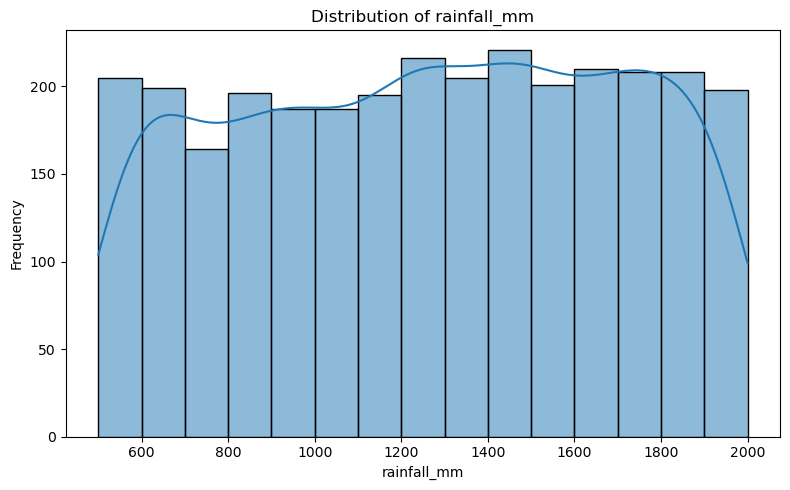

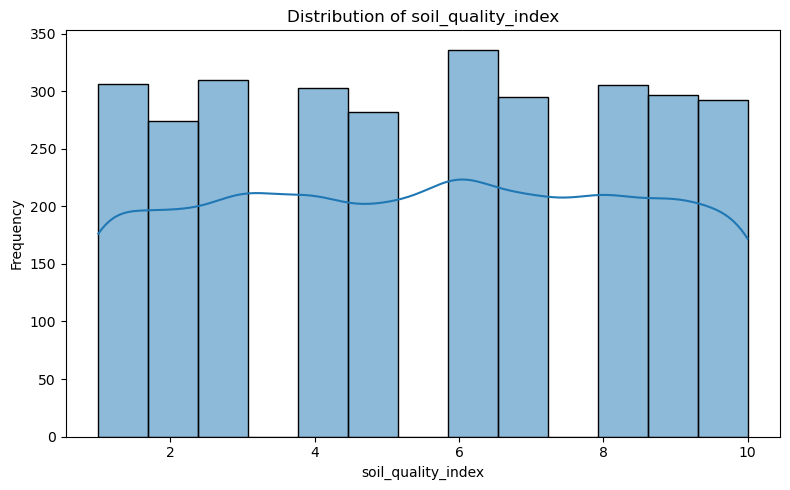

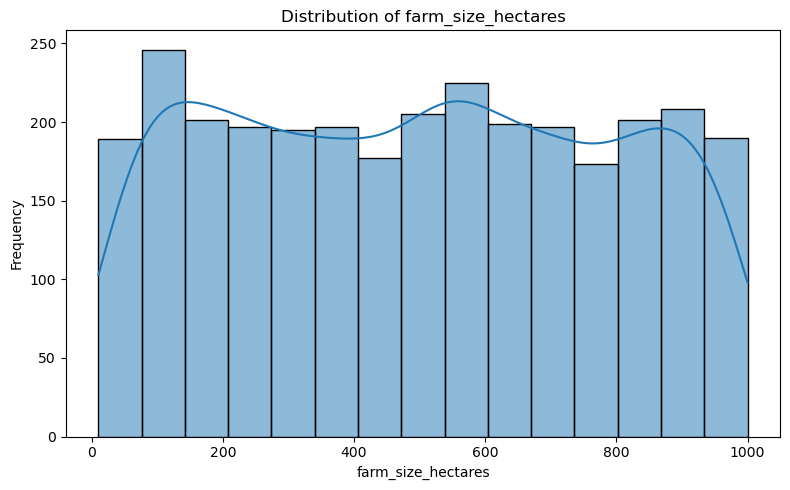

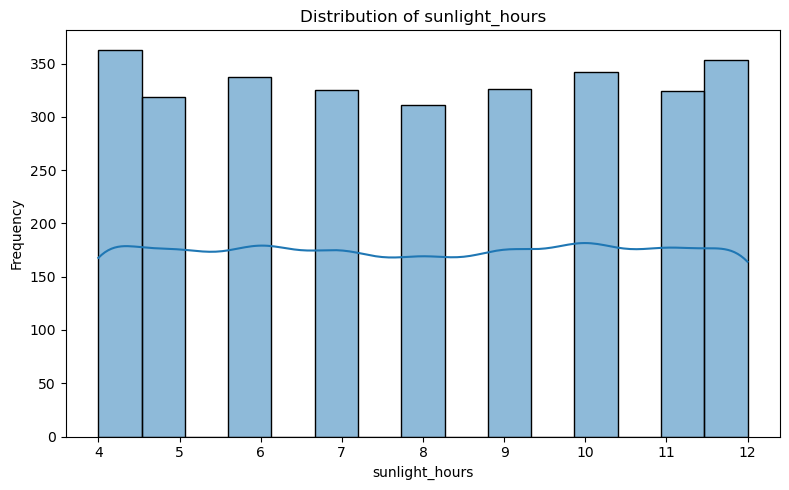

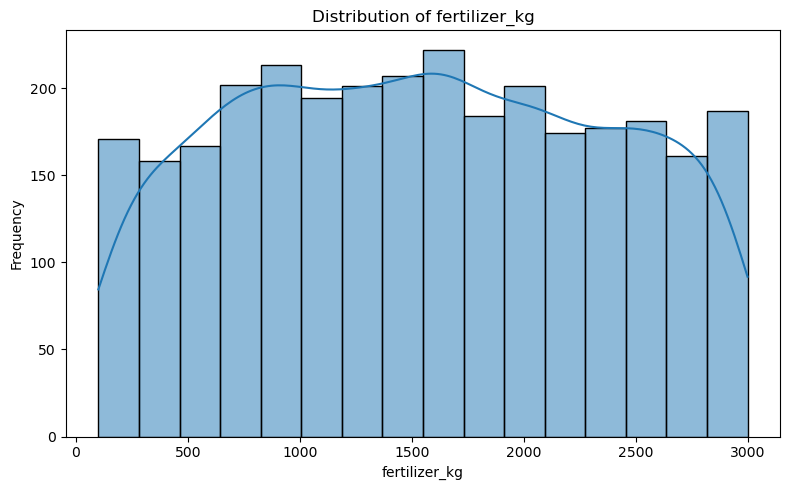

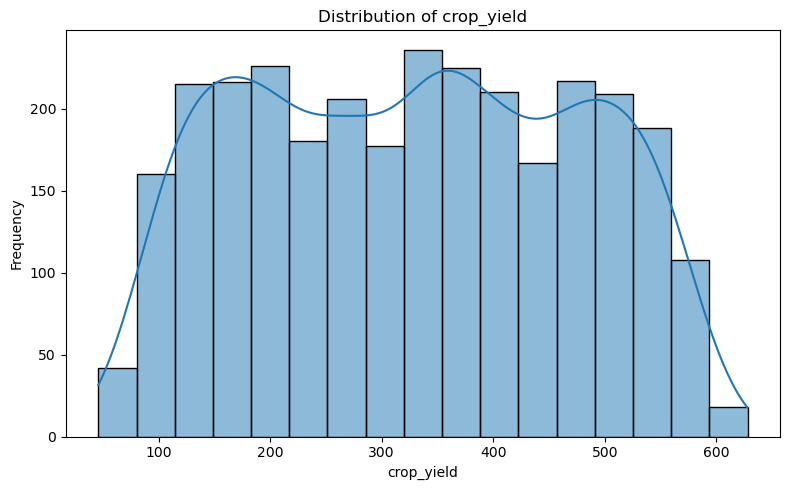

In [5]:
# ==========================================
# STEP 5 — NUMERICAL DISTRIBUTION ANALYSIS
# ==========================================

numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(df[column], kde=True)
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    
    plt.savefig(
        f"../Visualizations/distribution_{column}.png",
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()

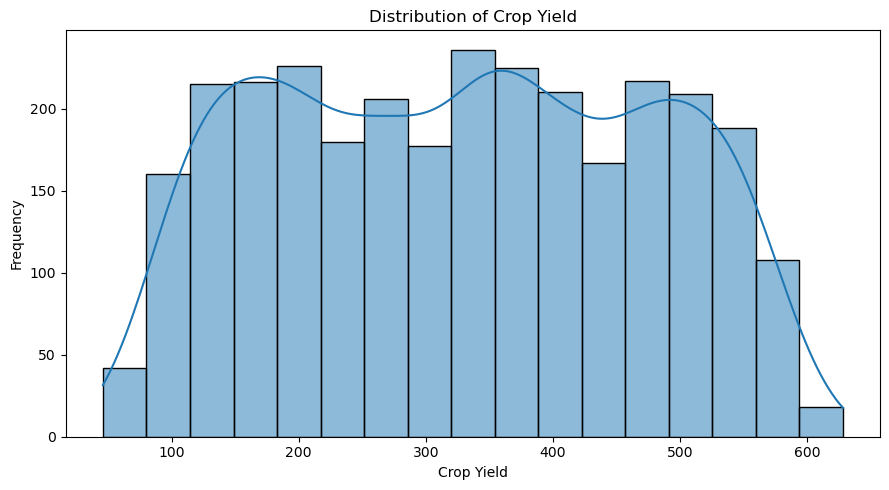

In [6]:
# ==========================================
# STEP 6 — CROP YIELD DISTRIBUTION
# ==========================================

plt.figure(figsize=(9, 5))

sns.histplot(
    df["crop_yield"],
    kde=True
)

plt.title("Distribution of Crop Yield")
plt.xlabel("Crop Yield")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../Visualizations/crop_yield_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

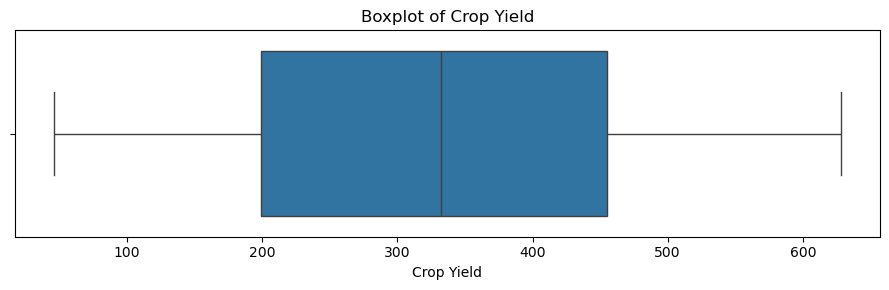

In [7]:
plt.figure(figsize=(9, 3))

sns.boxplot(x=df["crop_yield"])

plt.title("Boxplot of Crop Yield")
plt.xlabel("Crop Yield")

plt.tight_layout()

plt.savefig(
    "../Visualizations/crop_yield_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

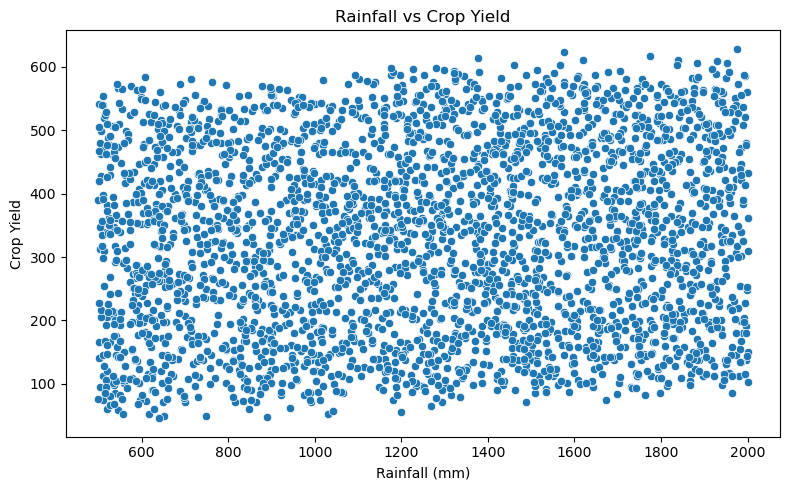

In [8]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="rainfall_mm",
    y="crop_yield"
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Crop Yield")

plt.tight_layout()

plt.savefig(
    "../Visualizations/rainfall_vs_yield.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

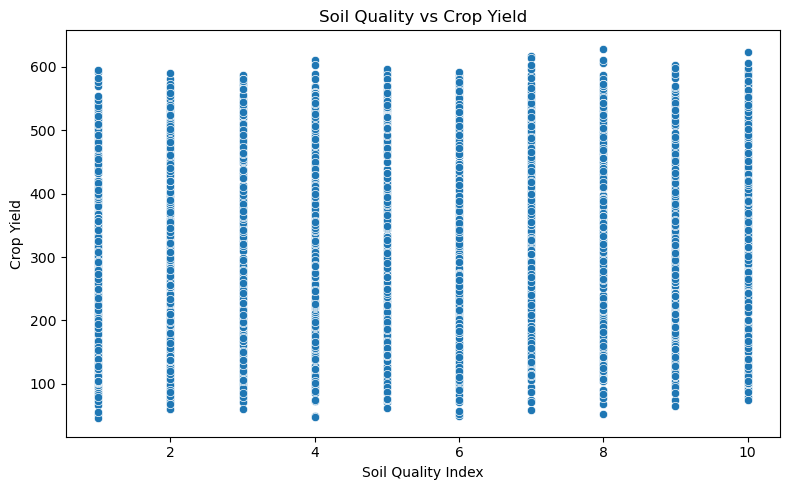

In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="soil_quality_index",
    y="crop_yield"
)

plt.title("Soil Quality vs Crop Yield")
plt.xlabel("Soil Quality Index")
plt.ylabel("Crop Yield")

plt.tight_layout()

plt.savefig(
    "../Visualizations/soil_quality_vs_yield.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

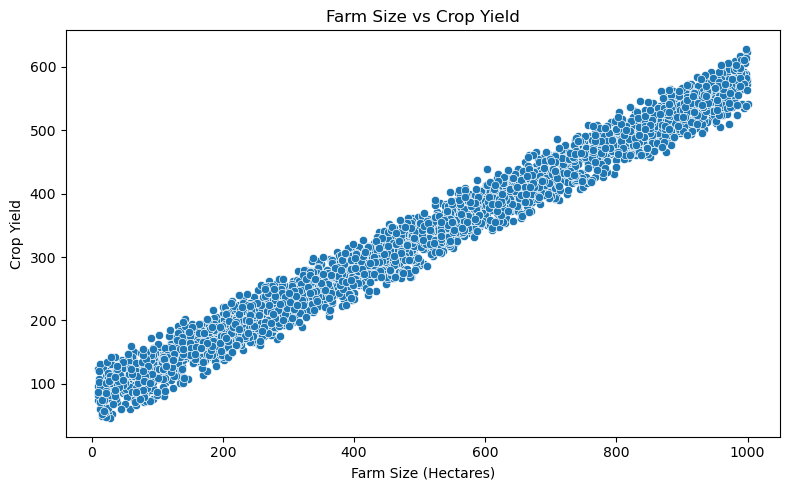

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="farm_size_hectares",
    y="crop_yield"
)

plt.title("Farm Size vs Crop Yield")
plt.xlabel("Farm Size (Hectares)")
plt.ylabel("Crop Yield")

plt.tight_layout()

plt.savefig(
    "../Visualizations/farm_size_vs_yield.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

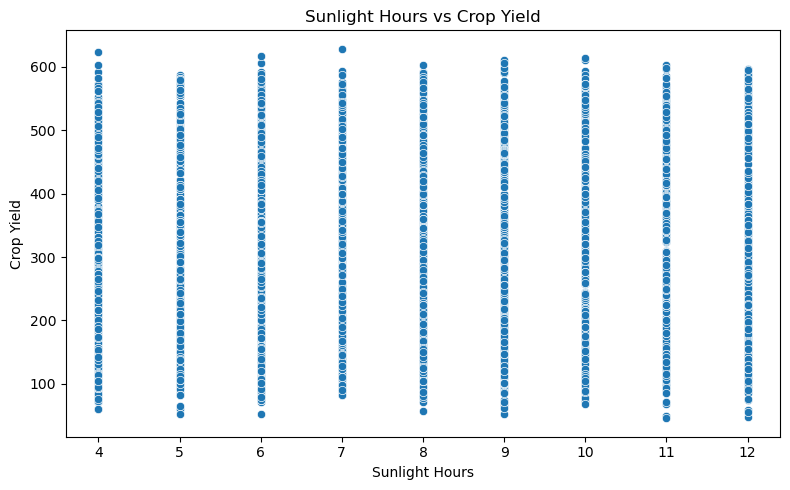

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="sunlight_hours",
    y="crop_yield"
)

plt.title("Sunlight Hours vs Crop Yield")
plt.xlabel("Sunlight Hours")
plt.ylabel("Crop Yield")

plt.tight_layout()

plt.savefig(
    "../Visualizations/sunlight_vs_yield.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

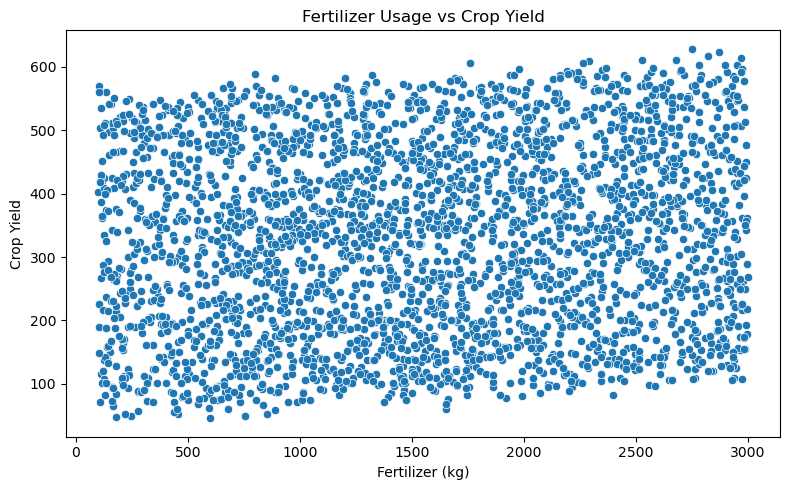

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="fertilizer_kg",
    y="crop_yield"
)

plt.title("Fertilizer Usage vs Crop Yield")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Crop Yield")

plt.tight_layout()

plt.savefig(
    "../Visualizations/fertilizer_vs_yield.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# ==========================================
# STEP 8 — CORRELATION ANALYSIS
# ==========================================

correlation_matrix = df.corr(numeric_only=True)

display(correlation_matrix)

,rainfall_mm,soil_quality_index,farm_size_hectares,sunlight_hours,fertilizer_kg,crop_yield
rainfall_mm,1.000000,-0.022198,0.001127,-0.005250,-0.029317,0.086339
soil_quality_index,-0.022198,1.000000,0.005829,0.002187,0.007254,0.043990
farm_size_hectares,0.001127,0.005829,1.000000,-0.010054,-0.008032,0.989201
sunlight_hours,-0.005250,0.002187,-0.010054,1.000000,0.016289,-0.006792
fertilizer_kg,-0.029317,0.007254,-0.008032,0.016289,1.000000,0.102023
crop_yield,0.086339,0.043990,0.989201,-0.006792,0.102023,1.000000


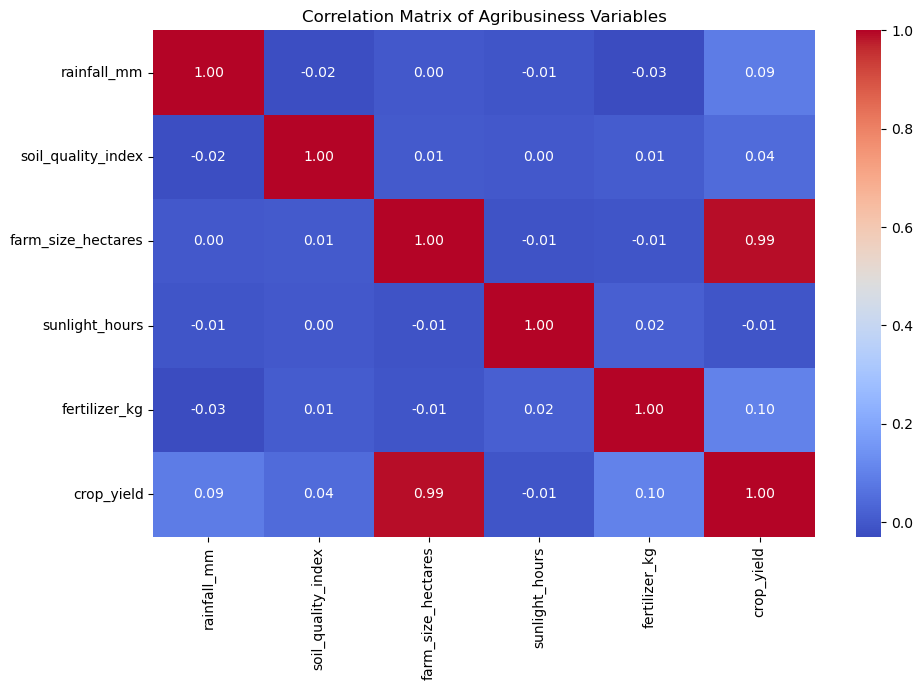

In [14]:
# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Agribusiness Variables")

plt.tight_layout()

plt.savefig(
    "../Visualizations/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# ==========================================
# STEP 9 — STRONGEST CORRELATIONS
# ==========================================

target_correlation = (
    correlation_matrix["crop_yield"]
    .drop("crop_yield")
    .sort_values(ascending=False)
)

print("Correlation of Features with Crop Yield:")
display(target_correlation)

Correlation of Features with Crop Yield:


farm_size_hectares    0.989201
fertilizer_kg         0.102023
rainfall_mm           0.086339
soil_quality_index    0.043990
sunlight_hours       -0.006792
Name: crop_yield, dtype: float64

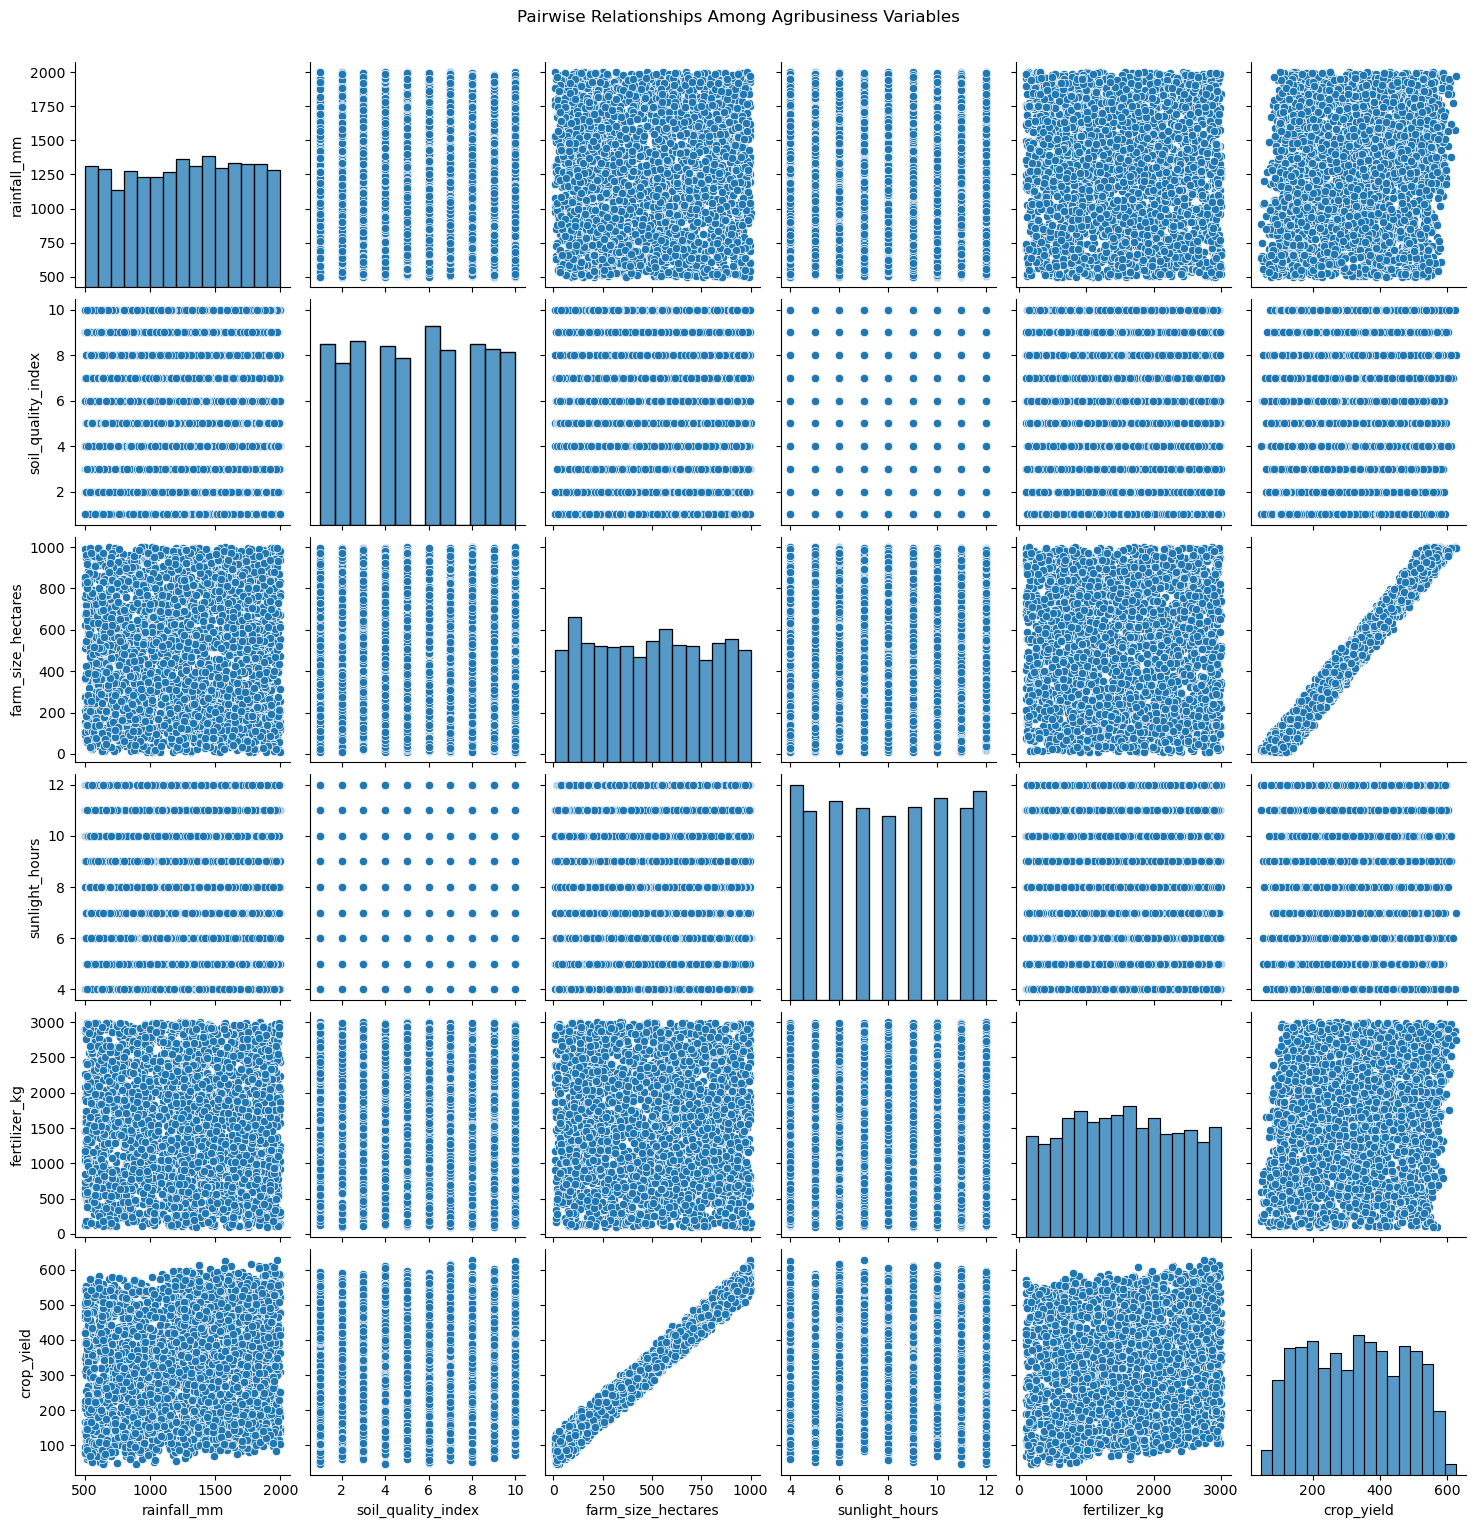

In [16]:
# ==========================================
# STEP 10 — PAIRWISE RELATIONSHIP ANALYSIS
# ==========================================

pairplot = sns.pairplot(df)

pairplot.fig.suptitle(
    "Pairwise Relationships Among Agribusiness Variables",
    y=1.02
)

pairplot.savefig(
    "../Visualizations/pairwise_relationships.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Key Findings

The Exploratory Data Analysis produced the following major findings:

1. The dataset contains 3,000 observations and 6 numerical variables.

2. No missing values were found in the cleaned dataset.

3. No duplicate records were identified.

4. Farm size shows an extremely strong positive relationship with crop yield, with a Pearson correlation coefficient of approximately 0.989.

5. Fertilizer usage has a weak positive relationship with crop yield, with a correlation of approximately 0.102.

6. Rainfall has a weak positive relationship with crop yield, with a correlation of approximately 0.086.

7. Soil quality shows a very weak positive relationship with crop yield, with a correlation of approximately 0.044.

8. Sunlight hours show almost no linear relationship with crop yield, with a correlation of approximately -0.007.

9. The scatterplot of farm size against crop yield shows a clear and strong upward linear pattern.

10. The remaining feature-versus-yield scatterplots show considerably more dispersion and weaker linear patterns.

## 12. Agribusiness Insights

The EDA provides several useful insights for an agribusiness context.

### 12.1 Farm Size and Crop Yield

Farm size is the strongest variable associated with crop yield in this dataset. The correlation coefficient of approximately 0.989 indicates a very strong positive linear relationship.

The scatterplot also shows a clear upward pattern, where larger farm sizes are associated with higher crop-yield values.

However, correlation should not be interpreted as direct causation. The relationship may also reflect how the dataset's target variable was generated.

### 12.2 Fertilizer Usage

Fertilizer usage has a weak positive relationship with crop yield. This suggests that fertilizer may contain some predictive information, but its individual linear relationship with yield is relatively small compared with farm size.

### 12.3 Rainfall

Rainfall shows a weak positive correlation with crop yield. The scatterplot contains substantial variation, indicating that rainfall alone does not strongly explain differences in crop yield in this dataset.

### 12.4 Soil Quality

Soil quality has a very weak positive correlation with crop yield. The observations are widely distributed across the different soil-quality levels, suggesting limited linear predictive strength when considered individually.

### 12.5 Sunlight Hours

Sunlight hours have an almost zero correlation with crop yield. The scatterplot does not show a clear increasing or decreasing linear pattern.

### Overall Insight

Among the available variables, farm size is clearly the dominant variable associated with crop yield. The other agricultural and environmental variables show comparatively weak individual linear relationships.

In [17]:
# ==========================================
# STEP 13 — CROP YIELD EXTREMES
# ==========================================

highest_yield = df.loc[df["crop_yield"].idxmax()]
lowest_yield = df.loc[df["crop_yield"].idxmin()]

print("Record with Highest Crop Yield:")
display(highest_yield.to_frame("Value"))

print("\nRecord with Lowest Crop Yield:")
display(lowest_yield.to_frame("Value"))

Record with Highest Crop Yield:


,Value
rainfall_mm,1975
soil_quality_index,8
farm_size_hectares,997
sunlight_hours,7
fertilizer_kg,2753
crop_yield,628



Record with Lowest Crop Yield:


,Value
rainfall_mm,639
soil_quality_index,1
farm_size_hectares,28
sunlight_hours,11
fertilizer_kg,597
crop_yield,46


In [18]:
# ==========================================
# STEP 14 — CROP YIELD QUARTILES
# ==========================================

yield_quartiles = df["crop_yield"].quantile([0.25, 0.50, 0.75])

print("Crop Yield Quartiles:")
display(yield_quartiles)

Crop Yield Quartiles:


0.25    199.0
0.50    332.0
0.75    455.0
Name: crop_yield, dtype: float64

In [19]:
# ==========================================
# STEP 15 — FEATURE CORRELATION RANKING
# ==========================================

correlation_ranking = (
    df.corr(numeric_only=True)["crop_yield"]
    .drop("crop_yield")
    .abs()
    .sort_values(ascending=False)
)

print("Features Ranked by Absolute Correlation with Crop Yield:")
display(correlation_ranking)

Features Ranked by Absolute Correlation with Crop Yield:


farm_size_hectares    0.989201
fertilizer_kg         0.102023
rainfall_mm           0.086339
soil_quality_index    0.043990
sunlight_hours        0.006792
Name: crop_yield, dtype: float64

## 13. Week 2 Conclusion

The Exploratory Data Analysis successfully examined the cleaned agribusiness dataset containing 3,000 observations and 6 numerical variables.

The analysis included dataset verification, descriptive statistics, distribution analysis, crop-yield analysis, feature-versus-target scatterplots, correlation analysis, and a correlation heatmap.

The most significant finding was the extremely strong positive relationship between farm size and crop yield, with a correlation coefficient of approximately 0.989. Fertilizer usage and rainfall showed weak positive relationships, while soil quality showed a very weak positive relationship. Sunlight hours showed almost no linear relationship with crop yield.

The visualizations supported the numerical correlation results. In particular, the Farm Size vs Crop Yield plot showed a clear upward linear pattern, while the other feature relationships were substantially more scattered.

These findings provide a useful foundation for the next stage of the internship project. In Week 3, machine learning models can be developed to predict crop yield using the available agricultural and environmental variables.

It should be noted that correlation describes statistical association and does not establish causation. In addition, the dataset should be considered carefully during modelling because the target variable may have a predefined relationship with the input variables.